Using device: cpu
Random seed set to: 1234
FiLM-HyperPINN params: 121,026
Epoch     1 | Loss: 1.741e+01 (PDE: 1.741e+01, BC(mon.): 0.000e+00, lr=1.0e-03)
Epoch   200 | Loss: 2.848e-01 (PDE: 2.848e-01, BC(mon.): 0.000e+00, lr=1.0e-03)
Epoch   400 | Loss: 3.162e-02 (PDE: 3.162e-02, BC(mon.): 0.000e+00, lr=1.0e-03)
Epoch   600 | Loss: 4.280e-02 (PDE: 4.280e-02, BC(mon.): 0.000e+00, lr=1.0e-03)
Epoch   800 | Loss: 3.158e-02 (PDE: 3.158e-02, BC(mon.): 0.000e+00, lr=1.0e-03)
Epoch  1000 | Loss: 2.175e-02 (PDE: 2.175e-02, BC(mon.): 0.000e+00, lr=1.0e-03)
Epoch  1200 | Loss: 5.067e-03 (PDE: 5.067e-03, BC(mon.): 0.000e+00, lr=1.0e-03)
Epoch  1400 | Loss: 6.093e-03 (PDE: 6.093e-03, BC(mon.): 0.000e+00, lr=1.0e-03)
Epoch  1600 | Loss: 8.016e-01 (PDE: 8.016e-01, BC(mon.): 0.000e+00, lr=5.0e-04)
Epoch  1800 | Loss: 4.627e-01 (PDE: 4.627e-01, BC(mon.): 0.000e+00, lr=5.0e-04)
Epoch  2000 | Loss: 9.597e-02 (PDE: 9.597e-02, BC(mon.): 0.000e+00, lr=5.0e-04)
Epoch  2200 | Loss: 6.457e-02 (PDE: 6.457e-02,

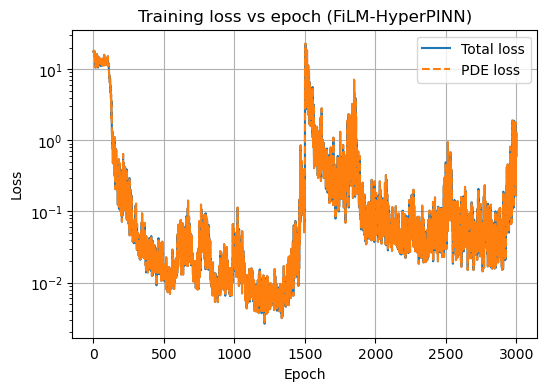

/tmp/ipykernel_30749/489709401.py:419: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale("log")


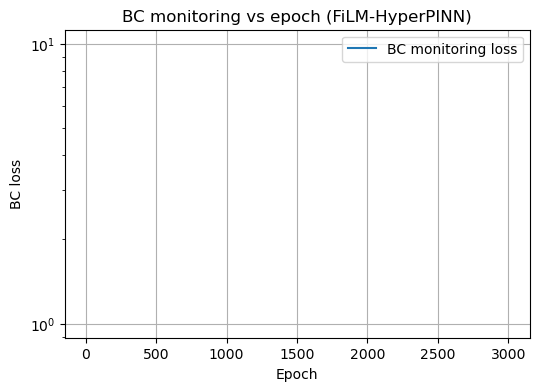

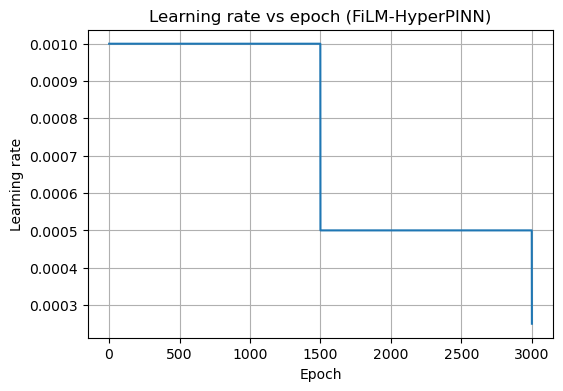

/tmp/ipykernel_30749/489709401.py:643: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded.load_state_dict(torch.load(MODEL_PATH, map_location=device))


Loaded model from: film_hyperpinn_poisson_model.pt

=== Test case 1/4: center_in_range ===
  (x0, y0, nu) = (0.500, 0.500, 0.070)
  Relative L2 error = 1.657e-02
  Saved per-case arrays to: outputs_hyperpinn/hyperpinn_case_00_center_in_range.npz

=== Test case 2/4: off_center_in_range ===
  (x0, y0, nu) = (0.450, 0.550, 0.090)
  Relative L2 error = 6.055e-03
  Saved per-case arrays to: outputs_hyperpinn/hyperpinn_case_01_off_center_in_range.npz

=== Test case 3/4: shifted_out_of_range ===
  (x0, y0, nu) = (0.300, 0.300, 0.060)
  Relative L2 error = 2.717e-01
  Saved per-case arrays to: outputs_hyperpinn/hyperpinn_case_02_shifted_out_of_range.npz

=== Test case 4/4: narrow_out_of_range ===
  (x0, y0, nu) = (0.500, 0.500, 0.030)
  Relative L2 error = 9.953e-02
  Saved per-case arrays to: outputs_hyperpinn/hyperpinn_case_03_narrow_out_of_range.npz

Saved solution comparison figure to: figures/film_hyperpinn_poisson_results.png


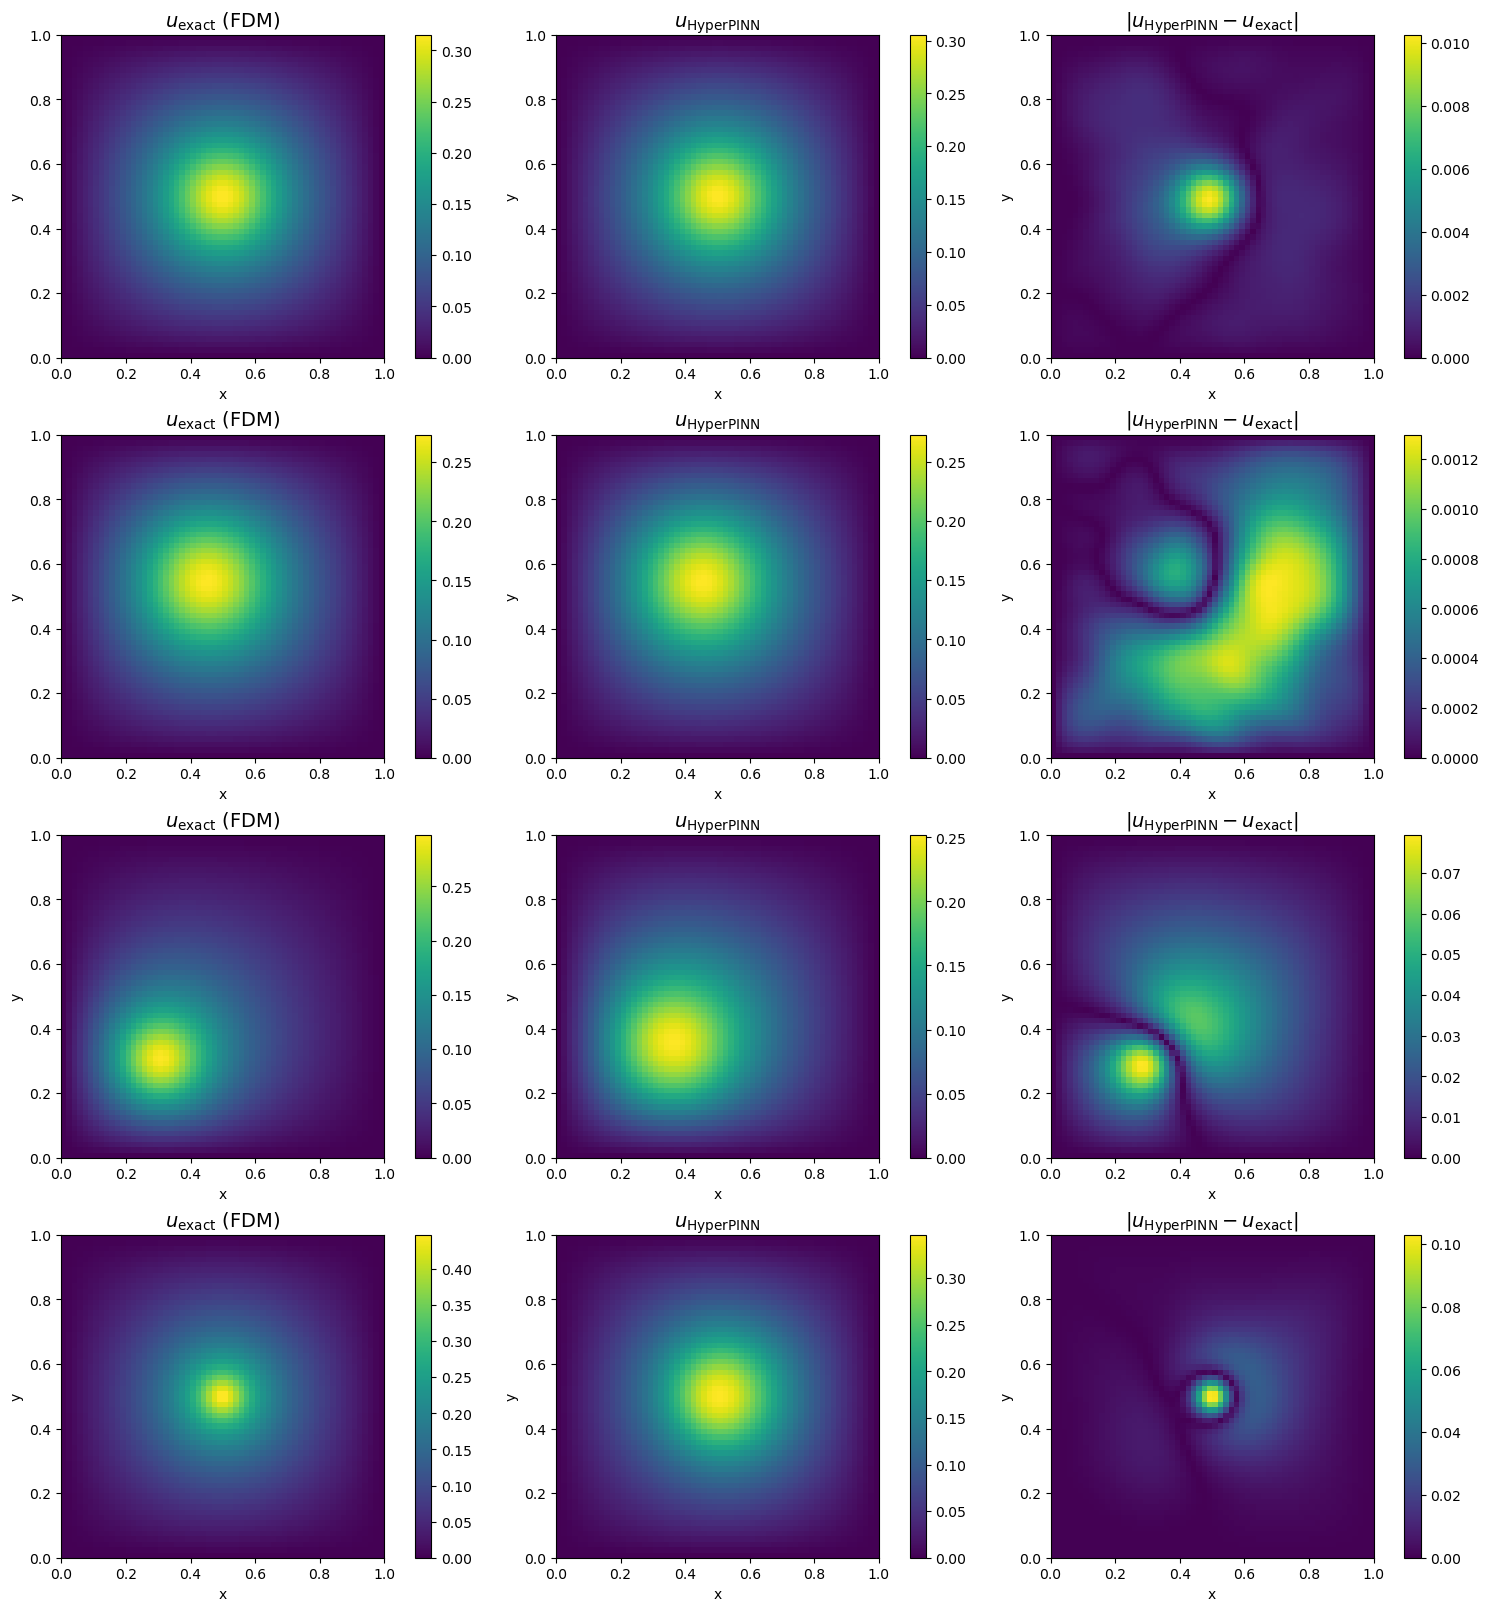


[Saved standardized bundle] outputs_hyperpinn/hyperpinn_bundle.npz
Bundle contains: x, y, params, case_names, u_exact, u_pred, abs_error (+ optional extras)

Summary of relative L2 errors:
  center_in_range          : 1.657e-02
  off_center_in_range      : 6.055e-03
  shifted_out_of_range     : 2.717e-01
  narrow_out_of_range      : 9.953e-02

Done.
Current directory: /home/vikas/Desktop/TWO_SHOTS/Vs_Neural_Operators/Poisson
Files: ['Poisson_03_PIDeepONet.ipynb', 'film_hyperpinn_poisson_model.pt', 'PLOTTING_CODE.ipynb', 'FIG_TC_01_KAPI_VS_NO.png', 'Poisson_02_HyperPINN.ipynb', 'Poisson_01_KAPI.ipynb', '.ipynb_checkpoints', 'outputs_hyperpinn', 'figures', 'outputs_pideeponet', 'v2.ipynb']


In [1]:
"""
FiLM-HyperPINN (Parametric PINN) baseline for 2D Poisson with Gaussian source on [0,1]^2:
    -Δu = f(x,y; x0, y0, nu),   u = 0 on boundary.
"""

import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR


# ============================================================
# Device + reproducibility
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

# Standardized directory for saving fields for later comparison plots
DATA_DIR = "outputs_hyperpinn"
os.makedirs(DATA_DIR, exist_ok=True)

MODEL_PATH = "film_hyperpinn_poisson_model.pt"

SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print("Random seed set to:", SEED)


# ============================================================
# Problem definition
# ============================================================
def gaussian_source(x, y, x0, y0, nu):
    """Gaussian source term used in all three baselines."""
    r2 = (x - x0) ** 2 + (y - y0) ** 2
    return (1.0 / (2.0 * torch.pi * nu**2)) * torch.exp(-r2 / (2.0 * nu**2))


# Training parameter ranges (same as your KAPI / PI-DeepONet)
x0_min, x0_max = 0.4, 0.6
y0_min, y0_max = 0.4, 0.6
nu_min, nu_max = 0.05, 0.1


def sample_pde_param(nu_min_curr=None, nu_max_curr=None):
    """
    Sample p=(x0,y0,nu) with:
      x0,y0 uniform in [0.4,0.6]
      nu log-uniform in [nu_min_curr, nu_max_curr]
    """
    if nu_min_curr is None:
        nu_min_curr = nu_min
    if nu_max_curr is None:
        nu_max_curr = nu_max

    x0 = x0_min + (x0_max - x0_min) * torch.rand(1, device=device)
    y0 = y0_min + (y0_max - y0_min) * torch.rand(1, device=device)

    u = torch.rand(1, device=device)
    nu_min_t = torch.tensor(nu_min_curr, device=device)
    nu_max_t = torch.tensor(nu_max_curr, device=device)
    nu = 10.0 ** (
        torch.log10(nu_min_t) + (torch.log10(nu_max_t) - torch.log10(nu_min_t)) * u
    )

    p = torch.stack([x0, y0, nu], dim=-1)  # (1,3)
    return p


def sample_collocation_points_p_dependent(
    N_int, N_bc, p, alpha=None, sigma_factor=3.0, device=device
):
    """
    p-dependent interior sampling:
      - fraction alpha near (x0,y0) with spread ~ sigma_factor*nu
      - remainder uniform in [0,1]^2

    boundary sampling:
      - uniform points on each side

    NOTE: This is consistent with your other two codes.
    """
    x0, y0, nu = p[0]

    if alpha is None:
        alpha = 0.9 if nu.item() < 0.06 else 0.7

    N_loc = int(alpha * N_int)
    N_uni = N_int - N_loc

    if N_loc > 0:
        loc_x = x0 + sigma_factor * nu * torch.randn(N_loc, 1, device=device)
        loc_y = y0 + sigma_factor * nu * torch.randn(N_loc, 1, device=device)
        loc_x = loc_x.clamp(0.0, 1.0)
        loc_y = loc_y.clamp(0.0, 1.0)
        xy_loc = torch.cat([loc_x, loc_y], dim=1)
    else:
        xy_loc = torch.empty(0, 2, device=device)

    if N_uni > 0:
        uni_x = torch.rand(N_uni, 1, device=device)
        uni_y = torch.rand(N_uni, 1, device=device)
        xy_uni = torch.cat([uni_x, uni_y], dim=1)
    else:
        xy_uni = torch.empty(0, 2, device=device)

    xy_int = torch.cat([xy_loc, xy_uni], dim=0)

    # boundary points (monitoring only; BC is hard-enforced in trial form)
    if N_bc > 0:
        N_side = N_bc // 4
        t = torch.rand(N_side, 1, device=device)

        xb = torch.cat(
            [
                torch.zeros(N_side, 1, device=device),
                torch.ones(N_side, 1, device=device),
                t,
                t,
            ],
            dim=0,
        )
        yb = torch.cat(
            [
                t,
                t,
                torch.zeros(N_side, 1, device=device),
                torch.ones(N_side, 1, device=device),
            ],
            dim=0,
        )
        xy_bc = torch.cat([xb, yb], dim=1)
    else:
        xy_bc = torch.empty(0, 2, device=device)

    return xy_int, xy_bc


# ============================================================
# FDM "exact" solver (same as other scripts)
# ============================================================
def poisson_exact_fdm(N=60, x0=0.5, y0=0.5, nu=0.05):
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    dx = x[1] - x[0]
    X, Y = np.meshgrid(x, y, indexing="ij")

    r2 = (X - x0) ** 2 + (Y - y0) ** 2
    f = (1.0 / (2.0 * np.pi * nu**2)) * np.exp(-r2 / (2.0 * nu**2))

    Nint = N - 2
    f_inner = f[1:-1, 1:-1].reshape(-1)

    e = np.ones(Nint)
    D2 = (np.diag(-2 * e) + np.diag(e[:-1], 1) + np.diag(e[:-1], -1)) / dx**2
    I = np.eye(Nint)

    L = np.kron(I, D2) + np.kron(D2, I)
    rhs = -f_inner

    u_inner = np.linalg.solve(L, rhs)
    u = np.zeros((N, N))
    u[1:-1, 1:-1] = u_inner.reshape(Nint, Nint)
    return x, y, u


# ============================================================
# Test cases (same as other scripts)
# ============================================================
test_cases = [
    ("center_in_range",      0.50, 0.50, 0.07),
    ("off_center_in_range",  0.45, 0.55, 0.09),
    ("shifted_out_of_range", 0.30, 0.30, 0.06),
    ("narrow_out_of_range",  0.50, 0.50, 0.03),
]


# ============================================================
# FiLM HyperPINN model
# ============================================================
class FiLMHyperPINN(nn.Module):
    """
    Trunk: MLP(x,y) with FiLM conditioning at each hidden layer.
    Hypernet: MLP(p) -> {gamma_l, beta_l} for each trunk hidden layer.

    Hard Dirichlet BC via:
      u(x,y;p) = x(1-x)y(1-y) * u_raw(x,y;p)
    """

    def __init__(self, trunk_width=128, trunk_depth=4, hyper_width=64):
        super().__init__()
        assert trunk_depth >= 2, "Need at least 2 hidden layers for FiLM to be meaningful."

        self.trunk_depth = trunk_depth
        self.trunk_width = trunk_width

        # Trunk: (2 -> W) -> ... -> (W -> 1)
        self.trunk_in = nn.Linear(2, trunk_width)
        self.trunk_h = nn.ModuleList([nn.Linear(trunk_width, trunk_width) for _ in range(trunk_depth - 1)])
        self.trunk_out = nn.Linear(trunk_width, 1)
        self.act = nn.Tanh()

        # FiLM blocks include the hidden outputs after trunk_in and each trunk_h layer
        film_blocks = trunk_depth
        out_dim = film_blocks * 2 * trunk_width  # gammas + betas

        self.hyper = nn.Sequential(
            nn.Linear(3, hyper_width),
            nn.Tanh(),
            nn.Linear(hyper_width, hyper_width),
            nn.Tanh(),
            nn.Linear(hyper_width, out_dim),
        )

        # p normalization constants (buffers)
        self.register_buffer("p_mean", torch.tensor([0.5, 0.5, 0.075], dtype=torch.float32))
        self.register_buffer("p_std",  torch.tensor([0.1, 0.1, 0.025], dtype=torch.float32))

        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, p, xy):
        """
        p:  (1,3)
        xy: (N,2)
        returns u: (N,)
        """
        assert p.shape[0] == 1, "Implementation assumes a single p per call."

        # FiLM params from hypernet
        p_norm = (p - self.p_mean.to(p.device)) / self.p_std.to(p.device)
        film = self.hyper(p_norm).view(1, self.trunk_depth, 2, self.trunk_width)  # (1,L,2,W)
        gammas = film[:, :, 0, :]  # (1,L,W)
        betas  = film[:, :, 1, :]  # (1,L,W)

        # Trunk forward with FiLM
        h = self.trunk_in(xy)  # (N,W)
        h = gammas[:, 0, :].view(1, -1) * h + betas[:, 0, :].view(1, -1)
        h = self.act(h)

        for li, layer in enumerate(self.trunk_h, start=1):
            h = layer(h)
            h = gammas[:, li, :].view(1, -1) * h + betas[:, li, :].view(1, -1)
            h = self.act(h)

        u_raw = self.trunk_out(h).view(-1) + self.bias  # (N,)

        # hard BC factor
        x = xy[:, 0:1]
        y = xy[:, 1:2]
        bc_factor = (x * (1.0 - x) * y * (1.0 - y)).view(-1)

        u = u_raw * bc_factor
        return u


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# ============================================================
# PDE residual: -Δu - f = 0
# ============================================================
def poisson_residual(model, p, xy_int):
    xy_int.requires_grad_(True)
    u = model(p, xy_int)  # (N,)

    grads = torch.autograd.grad(
        u, xy_int, grad_outputs=torch.ones_like(u), create_graph=True
    )[0]
    u_x = grads[:, 0]
    u_y = grads[:, 1]

    grads2_x = torch.autograd.grad(
        u_x, xy_int, grad_outputs=torch.ones_like(u_x), create_graph=True
    )[0]
    grads2_y = torch.autograd.grad(
        u_y, xy_int, grad_outputs=torch.ones_like(u_y), create_graph=True
    )[0]

    u_xx = grads2_x[:, 0]
    u_yy = grads2_y[:, 1]
    laplace_u = u_xx + u_yy

    x = xy_int[:, 0]
    y = xy_int[:, 1]
    x0, y0, nu = p[0, 0], p[0, 1], p[0, 2]
    f_val = gaussian_source(x, y, x0, y0, nu)

    return -laplace_u - f_val


# ============================================================
# Training loop (unchanged)
# ============================================================
def train_film_hyperpinn(
    n_int=2048,
    n_bc=256,
    epochs=3000,
    lr=1e-3,
    tasks_per_batch=8,
    trunk_width=128,
    trunk_depth=4,
    hyper_width=64,
):
    model = FiLMHyperPINN(
        trunk_width=trunk_width,
        trunk_depth=trunk_depth,
        hyper_width=hyper_width,
    ).to(device)

    print(f"FiLM-HyperPINN params: {count_params(model):,d}")

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = StepLR(optimizer, step_size=max(epochs // 2, 1), gamma=0.5)

    best_loss = float("inf")
    best_state = None

    history = {"epoch": [], "total_loss": [], "pde_loss": [], "bc_loss": [], "lr": []}

    for ep in range(1, epochs + 1):
        optimizer.zero_grad()

        total_loss = 0.0
        total_pde = 0.0
        total_bc = 0.0

        # ν-curriculum
        if ep <= epochs // 2:
            nu_min_curr, nu_max_curr = 0.08, nu_max
        else:
            nu_min_curr, nu_max_curr = nu_min, nu_max

        for _ in range(tasks_per_batch):
            p = sample_pde_param(nu_min_curr, nu_max_curr)

            xy_int, xy_bc = sample_collocation_points_p_dependent(
                n_int, n_bc, p, alpha=None, sigma_factor=3.0, device=device
            )

            res_int = poisson_residual(model, p, xy_int)
            loss_pde = torch.mean(res_int**2)

            # BC monitoring only (hard BC already enforced)
            if xy_bc.shape[0] > 0:
                u_bc = model(p, xy_bc)
                loss_bc = torch.mean(u_bc**2)
            else:
                loss_bc = torch.tensor(0.0, device=device)

            loss_task = loss_pde
            total_loss = total_loss + loss_task
            total_pde = total_pde + loss_pde
            total_bc = total_bc + loss_bc

        total_loss = total_loss / tasks_per_batch
        total_pde  = total_pde  / tasks_per_batch
        total_bc   = total_bc   / tasks_per_batch

        total_loss.backward()
        optimizer.step()
        scheduler.step()

        current_lr = scheduler.get_last_lr()[0]

        history["epoch"].append(ep)
        history["total_loss"].append(total_loss.item())
        history["pde_loss"].append(total_pde.item())
        history["bc_loss"].append(total_bc.item())
        history["lr"].append(current_lr)

        if total_loss.item() < best_loss:
            best_loss = total_loss.item()
            # save best weights on CPU (safer)
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if ep % 200 == 0 or ep == 1:
            print(
                f"Epoch {ep:5d} | Loss: {total_loss.item():.3e} "
                f"(PDE: {total_pde.item():.3e}, BC(mon.): {total_bc.item():.3e}, lr={current_lr:.1e})"
            )

    print(f"\nBest training loss = {best_loss:.3e}")
    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    return model, history


# ============================================================
# Optional: training curves
# ============================================================
def plot_training_curves(history):
    plt.figure(figsize=(6, 4))
    plt.plot(history["epoch"], history["total_loss"], label="Total loss")
    plt.plot(history["epoch"], history["pde_loss"], label="PDE loss", linestyle="--")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.yscale("log")
    plt.title("Training loss vs epoch (FiLM-HyperPINN)")
    plt.legend(); plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(history["epoch"], history["bc_loss"], label="BC monitoring loss")
    plt.xlabel("Epoch"); plt.ylabel("BC loss")
    plt.yscale("log")
    plt.title("BC monitoring vs epoch (FiLM-HyperPINN)")
    plt.legend(); plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(history["epoch"], history["lr"])
    plt.xlabel("Epoch"); plt.ylabel("Learning rate")
    plt.title("Learning rate vs epoch (FiLM-HyperPINN)")
    plt.grid(True)
    plt.show()


# ============================================================
# Evaluation + STANDARDIZED EXPORT
# ============================================================
def evaluate_and_plot_solutions(
    model,
    N=60,
    save_data=True,
    out_dir=DATA_DIR,
    export_prefix="hyperpinn"
):
    """
    Evaluate on `test_cases`, plot (Exact / Pred / |Error|),
    and export standardized arrays for later unified plotting.

    STANDARDIZED bundle keys (always present if save_data=True):
      x, y
      params
      case_names
      u_exact
      u_pred
      abs_error

    Extra keys are allowed (error, rel_l2, method, etc.).
    """
    model.eval()
    os.makedirs(out_dir, exist_ok=True)

    num_tests = len(test_cases)
    fig, axs = plt.subplots(num_tests, 3, figsize=(15, 4 * num_tests), constrained_layout=True)
    if num_tests == 1:
        axs = np.array([axs])

    # -----------------------------
    # Accumulators for standardized bundle
    # -----------------------------
    case_names = []
    params = []
    all_u_exact = []
    all_u_pred = []
    all_abs_err = []
    all_rel_l2 = []  # optional metric

    grid_x = None
    grid_y = None

    for i, (name, x0_test, y0_test, nu_test) in enumerate(test_cases):
        print(f"\n=== Test case {i+1}/{num_tests}: {name} ===")
        print(f"  (x0, y0, nu) = ({x0_test:.3f}, {y0_test:.3f}, {nu_test:.3f})")

        # Exact solution (FDM)
        xg, yg, u_exact = poisson_exact_fdm(N=N, x0=x0_test, y0=y0_test, nu=nu_test)

        # Grid points for NN evaluation
        Xg, Yg = np.meshgrid(xg, yg, indexing="ij")
        xy_grid = np.stack([Xg.reshape(-1), Yg.reshape(-1)], axis=1)
        xy_grid_t = torch.tensor(xy_grid, dtype=torch.float32, device=device)

        p_test = torch.tensor([[x0_test, y0_test, nu_test]], dtype=torch.float32, device=device)

        # Predict
        with torch.no_grad():
            u_pred_flat = model(p_test, xy_grid_t)
        u_pred = u_pred_flat.cpu().numpy().reshape(N, N)

        # Errors
        err = u_pred - u_exact
        abs_err = np.abs(err)

        # Relative L2 (optional)
        rel_L2 = np.linalg.norm(err.ravel()) / (np.linalg.norm(u_exact.ravel()) + 1e-12)
        print(f"  Relative L2 error = {rel_L2:.3e}")

        # Store for bundle
        case_names.append(name)
        params.append([x0_test, y0_test, nu_test])
        all_u_exact.append(u_exact.astype(np.float32))
        all_u_pred.append(u_pred.astype(np.float32))
        all_abs_err.append(abs_err.astype(np.float32))
        all_rel_l2.append(np.float32(rel_L2))

        if grid_x is None:
            grid_x = np.asarray(xg, dtype=np.float32)
            grid_y = np.asarray(yg, dtype=np.float32)

        # -----------------------------
        # Per-case export (debug-friendly; includes extra keys too)
        # -----------------------------
        if save_data:
            safe_name = "".join(ch if (ch.isalnum() or ch in "-_") else "_" for ch in name)
            per_case_path = os.path.join(out_dir, f"{export_prefix}_case_{i:02d}_{safe_name}.npz")
            np.savez_compressed(
                per_case_path,
                # Required data (per case)
                x=np.asarray(xg, dtype=np.float32),
                y=np.asarray(yg, dtype=np.float32),
                params=np.asarray([x0_test, y0_test, nu_test], dtype=np.float32),
                case_name=np.asarray(name),
                u_exact=u_exact.astype(np.float32),
                u_pred=u_pred.astype(np.float32),
                abs_error=abs_err.astype(np.float32),

                # Optional extras
                error=err.astype(np.float32),
                rel_l2=np.asarray(rel_L2, dtype=np.float32),
                method=np.asarray("HyperPINN"),
            )
            print(f"  Saved per-case arrays to: {per_case_path}")

        # -----------------------------
        # Plot row: Exact / Pred / Abs Error
        # -----------------------------
        ax0, ax1, ax2 = axs[i, 0], axs[i, 1], axs[i, 2]

        im0 = ax0.imshow(u_exact.T, origin="lower", extent=[0, 1, 0, 1])
        ax0.set_title(r"$u_{\mathrm{exact}}$ (FDM)", fontsize=14)
        ax0.set_xlabel("x"); ax0.set_ylabel("y")
        plt.colorbar(im0, ax=ax0)

        im1 = ax1.imshow(u_pred.T, origin="lower", extent=[0, 1, 0, 1])
        ax1.set_title(r"$u_{\mathrm{HyperPINN}}$", fontsize=14)
        ax1.set_xlabel("x"); ax1.set_ylabel("y")
        plt.colorbar(im1, ax=ax1)

        im2 = ax2.imshow(abs_err.T, origin="lower", extent=[0, 1, 0, 1])
        ax2.set_title(r"$|u_{\mathrm{HyperPINN}}-u_{\mathrm{exact}}|$", fontsize=14)
        ax2.set_xlabel("x"); ax2.set_ylabel("y")
        plt.colorbar(im2, ax=ax2)

    # Save the “local” HyperPINN figure (same behavior as before)
    results_path = os.path.join(FIG_DIR, "film_hyperpinn_poisson_results.png")
    plt.savefig(results_path, dpi=300, bbox_inches="tight")
    print(f"\nSaved solution comparison figure to: {results_path}")
    plt.show()

    # -----------------------------
    # STANDARDIZED bundle export (this is what the unified plotter should load)
    # -----------------------------
    if save_data:
        bundle_path = os.path.join(out_dir, f"{export_prefix}_bundle.npz")

        params_arr = np.asarray(params, dtype=np.float32)
        u_exact_arr = np.stack(all_u_exact, axis=0).astype(np.float32)
        u_pred_arr = np.stack(all_u_pred, axis=0).astype(np.float32)
        abs_err_arr = np.stack(all_abs_err, axis=0).astype(np.float32)

        # Optional extras
        err_arr = (u_pred_arr - u_exact_arr).astype(np.float32)
        rel_l2_arr = np.asarray(all_rel_l2, dtype=np.float32)

        np.savez_compressed(
            bundle_path,
            # -------- REQUIRED STANDARD KEYS --------
            x=grid_x,                                # (N,)
            y=grid_y,                                # (N,)
            params=params_arr,                       # (n_cases, 3)
            case_names=np.asarray(case_names),       # (n_cases,)
            u_exact=u_exact_arr,                     # (n_cases, N, N)
            u_pred=u_pred_arr,                       # (n_cases, N, N)
            abs_error=abs_err_arr,                   # (n_cases, N, N)

            # -------- OPTIONAL EXTRAS --------
            error=err_arr,
            rel_l2=rel_l2_arr,
            method=np.asarray("HyperPINN"),
        )

        print(f"\n[Saved standardized bundle] {bundle_path}")
        print("Bundle contains: x, y, params, case_names, u_exact, u_pred, abs_error (+ optional extras)")

        print("\nSummary of relative L2 errors:")
        for nm, e in zip(case_names, rel_l2_arr):
            print(f"  {nm:25s}: {e:.3e}")


# ============================================================
# Main
# ============================================================
if __name__ == "__main__":
    # Defaults comparable to your baselines
    n_int = 2048
    n_bc = 256
    epochs = 3000
    lr = 1e-3
    tasks_per_batch = 8

    # HyperPINN capacity knobs
    trunk_width = 128
    trunk_depth = 4
    hyper_width = 64

    # Train
    model, history = train_film_hyperpinn(
        n_int=n_int,
        n_bc=n_bc,
        epochs=epochs,
        lr=lr,
        tasks_per_batch=tasks_per_batch,
        trunk_width=trunk_width,
        trunk_depth=trunk_depth,
        hyper_width=hyper_width,
    )

    # Save trained model
    torch.save(model.state_dict(), MODEL_PATH)
    print(f"\nModel saved to: {MODEL_PATH}")

    # Optional training curves
    plot_training_curves(history)

    # Reload model (optional but keeps workflow consistent)
    loaded = FiLMHyperPINN(trunk_width=trunk_width, trunk_depth=trunk_depth, hyper_width=hyper_width).to(device)
    loaded.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    loaded.eval()
    print("Loaded model from:", MODEL_PATH)

    # Evaluate + export standardized outputs
    evaluate_and_plot_solutions(
        loaded,
        N=60,
        save_data=True,
        out_dir=DATA_DIR,
        export_prefix="hyperpinn"
    )

    print("\nDone.")
    print("Current directory:", os.getcwd())
    print("Files:", os.listdir("."))
